Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'B0005'])
Fields: ('cycle',)
Number of cycles: 616
Available fields in first cycle: ('type', 'ambient_temperature', 'time', 'data')
   time_s  current_A  voltage_V     temp_C
0   0.000  -0.004902   4.191492  24.330034
1  16.781  -0.001478   4.190749  24.325993
2  35.703  -2.012528   3.974871  24.389085
3  53.781  -2.013979   3.951717  24.544752
4  71.922  -2.011144   3.934352  24.731385


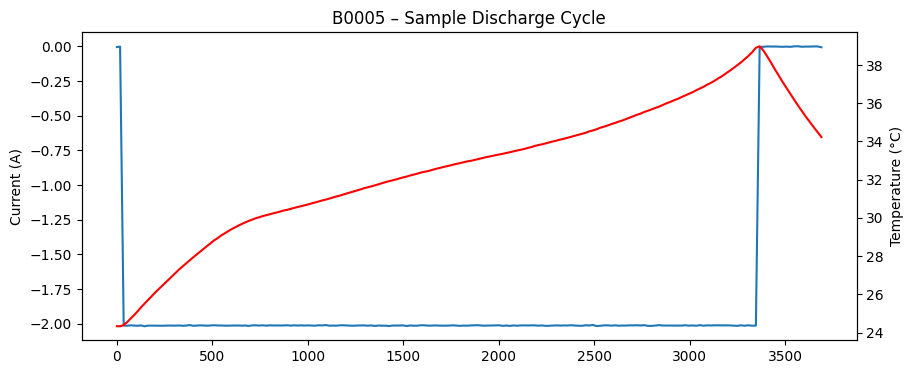

In [2]:
import os
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt

# Path to dataset
data_dir = "../data"   # adjust if needed
file_path = os.path.join(data_dir, "B0005.mat")

# Load .mat file
mat = sio.loadmat(file_path)

# Inspect top-level keys
print("Keys in .mat file:", mat.keys())

# The actual cycles are stored in 'B0005' struct
battery = mat['B0005'][0,0]
print("Fields:", battery.dtype.names)

# Check what’s inside
cycles = battery['cycle'][0]
print("Number of cycles:", len(cycles))
print("Available fields in first cycle:", cycles[0].dtype.names)

# Example: extract data from 1st discharge cycle
for c in cycles:
    if c['type'][0] == 'discharge':
        time = c['data'][0,0]['Time'][0]
        current = c['data'][0,0]['Current_measured'][0]
        voltage = c['data'][0,0]['Voltage_measured'][0]
        temp = c['data'][0,0]['Temperature_measured'][0]
        break

# Put into DataFrame
df = pd.DataFrame({
    "time_s": time,
    "current_A": current,
    "voltage_V": voltage,
    "temp_C": temp
})

print(df.head())

# Plot quick look
fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(df['time_s'], df['current_A'], label="Current (A)")
ax1.set_ylabel("Current (A)")
ax2 = ax1.twinx()
ax2.plot(df['time_s'], df['temp_C'], color="r", label="Temp (C)")
ax2.set_ylabel("Temperature (°C)")
plt.title("B0005 – Sample Discharge Cycle")
plt.show()


Fitted internal resistance: 0.074190 Ω
Fitted heat transfer (hA): 0.018136 W/K


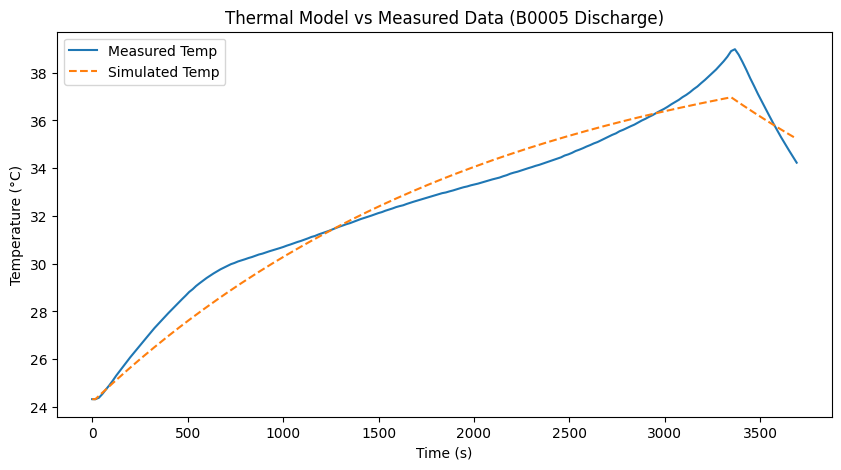

In [3]:
import numpy as np
from scipy.optimize import curve_fit

# Parameters (some fixed, some to fit)
m = 0.045          # mass of 18650 cell (kg ~45 g)
Cp = 900           # J/kgK (approx for Li-ion)
T_amb = c['ambient_temperature'][0][0]  # dataset ambient temp
dt = np.mean(np.diff(df['time_s']))     # timestep (s)

# Define thermal model simulation
def simulate_temp(I, R_internal, hA):
    T = np.zeros_like(I, dtype=float)
    T[0] = df['temp_C'].iloc[0]
    for t in range(1, len(I)):
        Q_gen = (I[t]**2) * R_internal
        Q_loss = hA * (T[t-1] - T_amb)
        dT = (Q_gen - Q_loss) * dt / (m * Cp)
        T[t] = T[t-1] + dT
    return T

# Wrapper for curve fitting
def model_for_fit(x, R_internal, hA):
    return simulate_temp(df['current_A'].values, R_internal, hA)

# Actual measured temperatures
y_meas = df['temp_C'].values

# Initial guesses
guess = [0.01, 0.1]   # R_internal=10 mΩ, hA=0.1 W/K approx

# Fit model
popt, pcov = curve_fit(model_for_fit, df['time_s'], y_meas, p0=guess)

R_fit, hA_fit = popt
print(f"Fitted internal resistance: {R_fit:.6f} Ω")
print(f"Fitted heat transfer (hA): {hA_fit:.6f} W/K")

# Simulate with fitted params
y_sim = simulate_temp(df['current_A'].values, R_fit, hA_fit)

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(df['time_s'], y_meas, label="Measured Temp")
plt.plot(df['time_s'], y_sim, label="Simulated Temp", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("Thermal Model vs Measured Data (B0005 Discharge)")
plt.show()


   cycle     R_fit    hA_fit
0      2  0.074190  0.018136
1      4  0.072998  0.017482
2      6  0.072514  0.017554
3      8  0.070731  0.016911
4     10  0.069654  0.016631


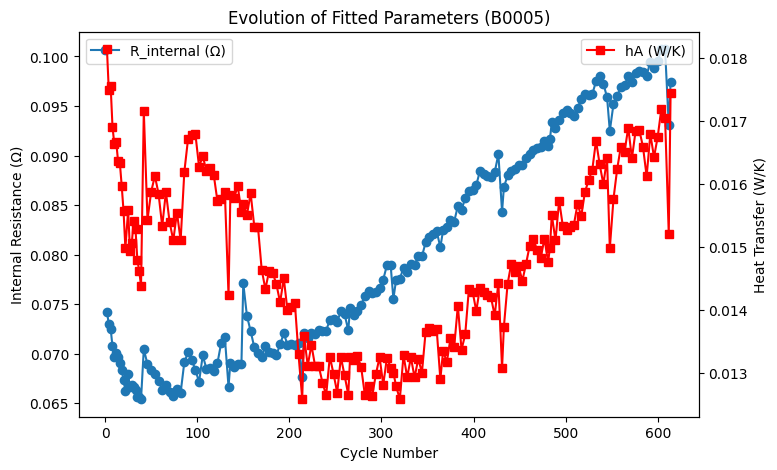

In [4]:
results = []

# Loop over all cycles
for idx, c in enumerate(cycles):
    if c['type'][0] != 'discharge':
        continue

    time = c['data'][0,0]['Time'][0]
    current = c['data'][0,0]['Current_measured'][0]
    temp = c['data'][0,0]['Temperature_measured'][0]
    T_amb = c['ambient_temperature'][0][0]

    if len(time) < 10:  # skip tiny cycles
        continue

    df_cycle = pd.DataFrame({
        "time_s": time,
        "current_A": current,
        "temp_C": temp
    })

    dt = np.mean(np.diff(df_cycle['time_s']))

    def simulate_temp(I, R_internal, hA):
        T = np.zeros_like(I, dtype=float)
        T[0] = df_cycle['temp_C'].iloc[0]
        for t in range(1, len(I)):
            Q_gen = (I[t]**2) * R_internal
            Q_loss = hA * (T[t-1] - T_amb)
            dT = (Q_gen - Q_loss) * dt / (m * Cp)
            T[t] = T[t-1] + dT
        return T

    def model_for_fit(x, R_internal, hA):
        return simulate_temp(df_cycle['current_A'].values, R_internal, hA)

    y_meas = df_cycle['temp_C'].values

    try:
        popt, _ = curve_fit(model_for_fit, df_cycle['time_s'], y_meas, p0=[0.01, 0.1], maxfev=5000)
        R_fit, hA_fit = popt
        results.append({"cycle": idx+1, "R_fit": R_fit, "hA_fit": hA_fit})
    except RuntimeError:
        continue

# Save results
df_results = pd.DataFrame(results)
print(df_results.head())

# Plot parameter evolution
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(df_results['cycle'], df_results['R_fit'], '-o', label="R_internal (Ω)")
ax1.set_ylabel("Internal Resistance (Ω)")
ax2 = ax1.twinx()
ax2.plot(df_results['cycle'], df_results['hA_fit'], '-s', color="r", label="hA (W/K)")
ax2.set_ylabel("Heat Transfer (W/K)")
ax1.set_xlabel("Cycle Number")
plt.title("Evolution of Fitted Parameters (B0005)")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


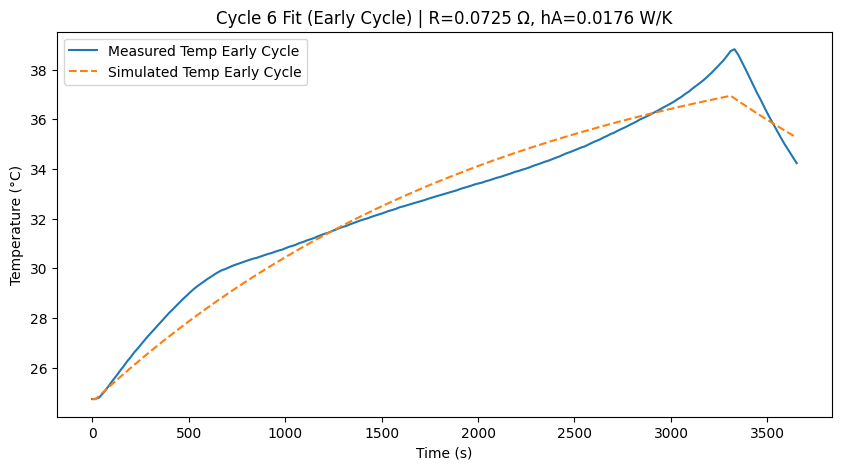

In [5]:
def plot_cycle_fit(cycle_index, label=""):
    c = cycles[cycle_index]
    if c['type'][0] != 'discharge':
        return
    
    time = c['data'][0,0]['Time'][0]
    current = c['data'][0,0]['Current_measured'][0]
    temp = c['data'][0,0]['Temperature_measured'][0]
    T_amb = c['ambient_temperature'][0][0]
    df_cycle = pd.DataFrame({"time_s": time, "current_A": current, "temp_C": temp})
    dt = np.mean(np.diff(df_cycle['time_s']))
    
    # Reuse simulate function
    def simulate_temp(I, R_internal, hA):
        T = np.zeros_like(I, dtype=float)
        T[0] = df_cycle['temp_C'].iloc[0]
        for t in range(1, len(I)):
            Q_gen = (I[t]**2) * R_internal
            Q_loss = hA * (T[t-1] - T_amb)
            dT = (Q_gen - Q_loss) * dt / (m * Cp)
            T[t] = T[t-1] + dT
        return T
    
    # Fit parameters
    y_meas = df_cycle['temp_C'].values
    popt, _ = curve_fit(lambda x, R, hA: simulate_temp(df_cycle['current_A'].values, R, hA),
                        df_cycle['time_s'], y_meas, p0=[0.01, 0.1], maxfev=5000)
    R_fit, hA_fit = popt
    
    # Simulate
    y_sim = simulate_temp(df_cycle['current_A'].values, R_fit, hA_fit)
    
    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(df_cycle['time_s'], y_meas, label=f"Measured Temp {label}")
    plt.plot(df_cycle['time_s'], y_sim, '--', label=f"Simulated Temp {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.title(f"Cycle {cycle_index+1} Fit ({label}) | R={R_fit:.4f} Ω, hA={hA_fit:.4f} W/K")
    plt.show()

# Plot early cycle (e.g. cycle 5) and late cycle (e.g. cycle 150)
plot_cycle_fit(5, label="Early Cycle")
plot_cycle_fit(150, label="Late Cycle")


In [6]:
# Save parameter evolution to CSV
output_path = "../results/parameter_evolution_B0005.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_results.to_csv(output_path, index=False)
print(f"Results saved to {output_path}")


Results saved to ../results/parameter_evolution_B0005.csv


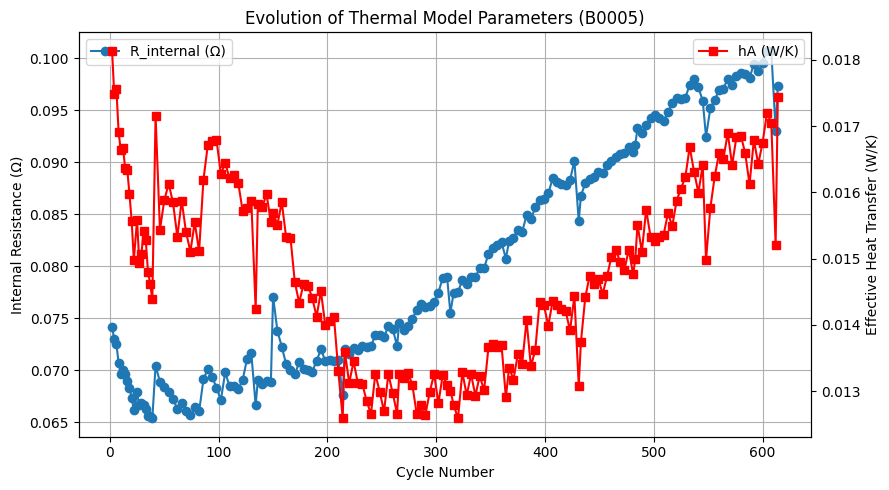

In [7]:
# Reload saved results
csv_path = "../results/parameter_evolution_B0005.csv"
df_params = pd.read_csv(csv_path)

# Plot evolution of internal resistance and heat transfer
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(df_params['cycle'], df_params['R_fit'], '-o', label="R_internal (Ω)")
ax1.set_ylabel("Internal Resistance (Ω)")
ax1.set_xlabel("Cycle Number")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(df_params['cycle'], df_params['hA_fit'], '-s', color="r", label="hA (W/K)")
ax2.set_ylabel("Effective Heat Transfer (W/K)")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Evolution of Thermal Model Parameters (B0005)")
plt.tight_layout()
plt.show()